# Off-Axis Holography Phase Retrieval

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from Phase_Simulation import (
    load_hologram,
    compute_fft,
    isolate_sideband,
    reconstruct_complex_field,
    extract_phase,
    plot_hologram,
    plot_spectrum,
    plot_sideband_selection,
    plot_reconstructed_amplitude,
    plot_phase_comparison,
    plot_results,
    run_pipeline,
)
%matplotlib inline

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from PIL import Image

def process_and_plot(path, title):
    # Load image
    img = np.array(Image.open(path).convert('L')).astype(np.float64)

    # Step 1: Remove low-frequency background (DC subtraction)
    bg_blur = gaussian_filter(img, sigma=50)
    img_corr = img - bg_blur

    # Step 2: Normalize to [0, 1]
    img_corr = (img_corr - img_corr.min()) / (img_corr.max() - img_corr.min())

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img,          cmap='gray'); axes[0].set_title('Original')
    axes[1].imshow(img_corr,     cmap='gray'); axes[1].set_title('BG Removed')
    # axes[2].imshow(img_windowed, cmap='gray'); axes[2].set_title('Windowed')

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{title}_result.png', dpi=300, bbox_inches='tight')
    plt.show()

    return img_corr

## Load hologram (512x512)

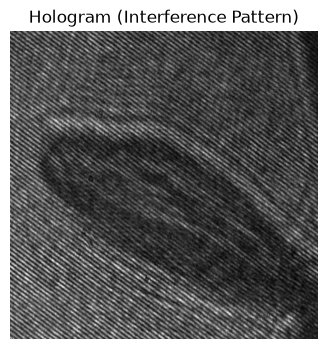

In [19]:
hologram = load_hologram("img/fly.bmp", size=512)
plot_hologram(hologram)

## FFT spectrum

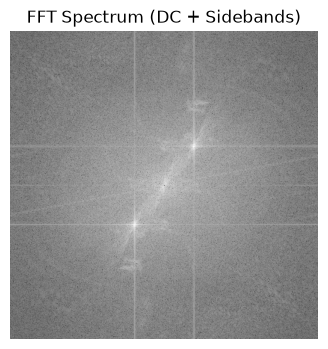

In [6]:
H = compute_fft(hologram)
plot_spectrum(H)

## Isolate +1 sideband

Sideband at pixel: row=191, col=305  (DC centre at 256,256; offset = -65, 49)


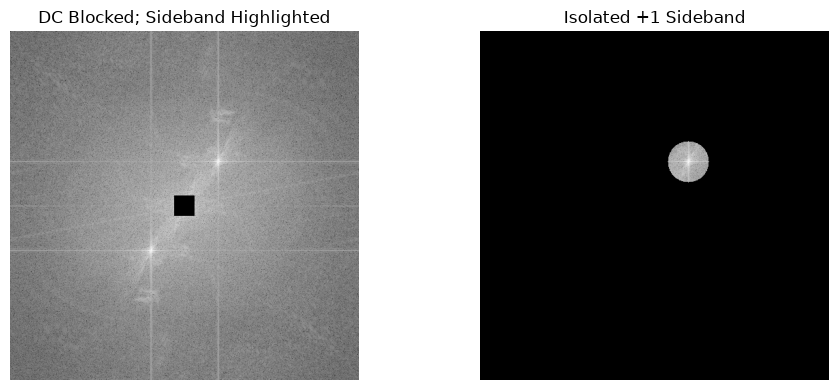

In [8]:
H_filtered, H_mag, cy, cx = isolate_sideband(H, radius=30, dc_block=15)
plot_sideband_selection(H_mag, H_filtered)

## Inverse FFT

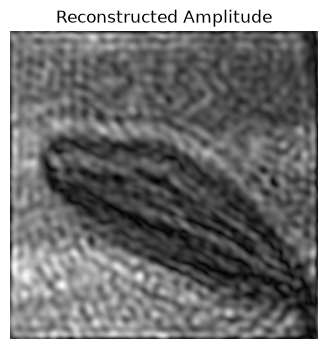

In [9]:
complex_field = reconstruct_complex_field(H_filtered, cy, cx)
plot_reconstructed_amplitude(complex_field)

## Unwrap phase

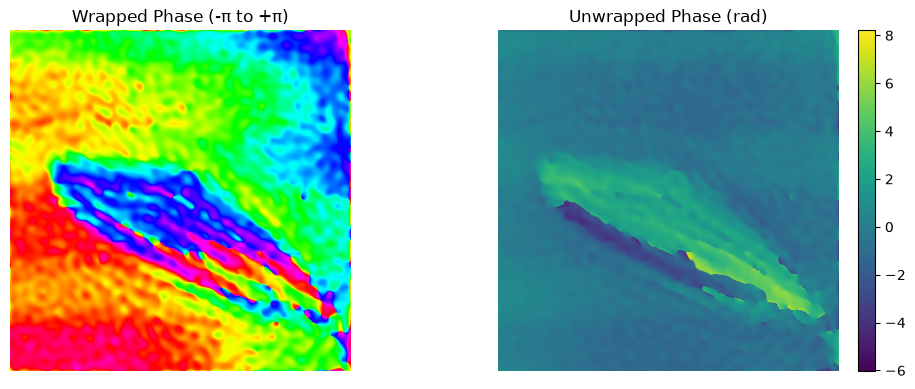

[[ 0.33930887  0.28987188  0.23495067 ...  3.19007832  3.15495423
   3.11484178]
 [ 0.42799222  0.40993134  0.38965876 ...  3.19185646  3.18607591
   3.17433424]
 [ 0.49592693  0.49955825  0.50223438 ...  3.19220036  3.21079726
   3.22101175]
 ...
 [ 1.35474676  1.1760024   1.00186606 ... -1.69715295 -1.85438037
  -2.0218871 ]
 [ 1.52030103  1.38236601  1.23668404 ... -1.67419867 -1.78488436
  -1.90371343]
 [ 1.66202378  1.57110048  1.47091966 ... -1.66185962 -1.7318199
  -1.80758602]]


In [17]:
wrapped_phase, unwrapped_phase = extract_phase(complex_field)
plot_phase_comparison(wrapped_phase, unwrapped_phase)
# save unwrapped phase as an image
plt.imsave("unwrapped_phase.png", unwrapped_phase)
print(unwrapped_phase)

## Full Pipeline

Sideband at pixel: row=184, col=269  (DC centre at 256,256; offset = -72, 13)
Pipeline visualisation saved as plots/pipeline_visualisation.png


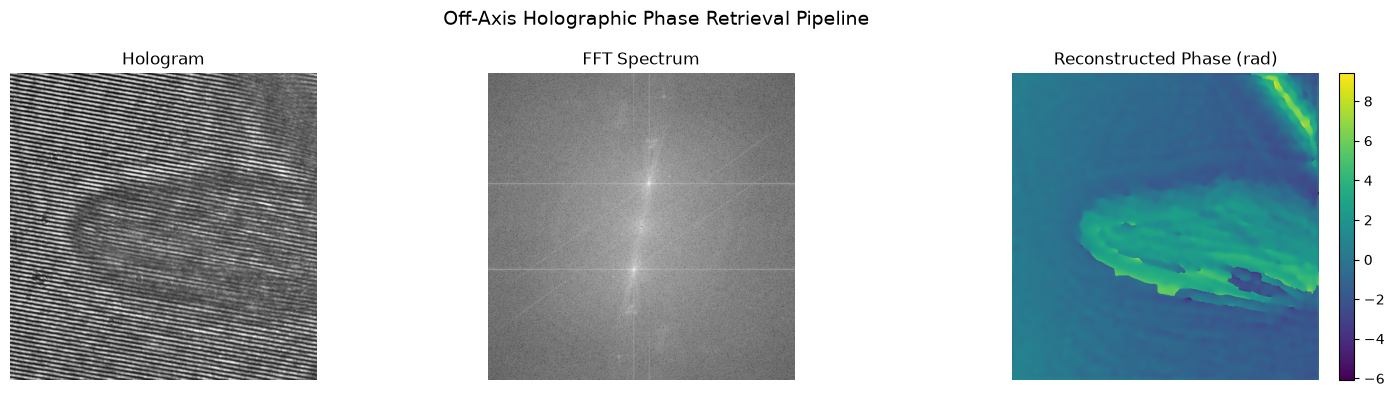

In [21]:
results = run_pipeline("img/fly2.bmp", N=512)